In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Scikit-learn imports
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

In [3]:
# plotting
from matplotlib.colors import ListedColormap

In [4]:
def plot_decision_regions(X,y,classifier,test_idx=None,resolution=0.02):
    markers = ('o','s','^','v','<')
    colors = ('red','blue','lightgreen','gray','cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:,0].min()-1, X[:,0].max()+1
    x2_min, x2_max = X[:,1].min()-1, X[:,1].max()+1

    xx1, xx2 = np.meshgrid(np.arange(x1_min,x1_max,resolution),
                           np.arange(x2_min,x2_max,resolution))
    
    lab = classifier.predict(np.array([xx1.ravel(),xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1,xx2,lab,alpha=0.3,cmap=cmap)
    plt.xlim(xx1.min(),xx1.max())
    plt.ylim(xx2.min(),xx2.max())

    for idx,cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y==cl,0],
                    y=X[y==cl,1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx],
                    label=f'Class {cl}',
                    edgecolor='black')
    # highlight test samples
    if test_idx:
        print(X.shape, test_idx)
        X_test, y_test = X[test_idx,:], y[test_idx]
        print(X_test.shape)
        plt.scatter(X_test[:,0],
                    X_test[:,1],
                    c='none',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100,
                    label='test set')


In [5]:
def entropy(p):
    return -p*np.log2(p) - (1-p)*np.log2((1-p))

In [6]:
x = np.arange(0.0,1.0,0.01)
ent = [entropy(p) if p!=0 else None for p in x]

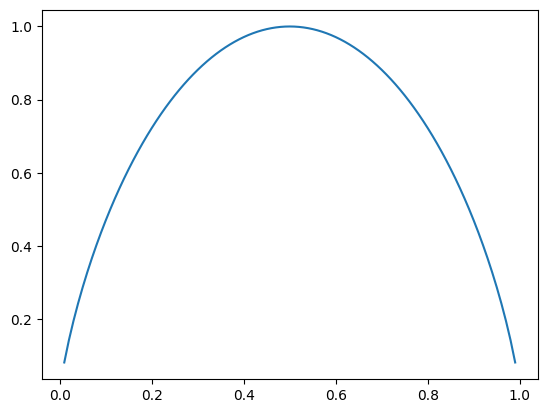

In [7]:
plt.plot(x,ent)
plt.show()

In [8]:
def load_iris_data():
    # load iris data from sklearn
    iris = datasets.load_iris()
    X = iris.data[:, [2, 3]]
    y = iris.target
    return X,y

def preprocess_data(X,y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y,shuffle=True,)
    sc = StandardScaler()
    sc.fit(X_train)
    X_train_std = sc.transform(X_train)
    X_test_std = sc.transform(X_test)
    return X_train_std,X_test_std,y_train,y_test

In [9]:
from sklearn.tree import DecisionTreeClassifier

In [10]:
tree_model = DecisionTreeClassifier(criterion='gini',max_depth=4,
                                    random_state=1)
X,y = load_iris_data()
X_train_std,X_test_std,y_train,y_test = preprocess_data(X,y)

In [11]:
tree_model.fit(X_train_std,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,1
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
X_combined = np.vstack((X_train_std,X_test_std))
y_combined = np.hstack((y_train,y_test))

(150, 2) range(105, 140)
(35, 2)


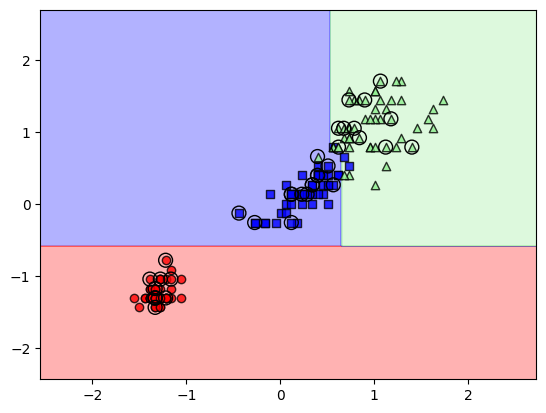

In [13]:
plot_decision_regions(X_combined,y_combined,
                      classifier=tree_model,
                      test_idx=range(105,140))

In [14]:
from sklearn import tree

[Text(0.25, 0.9, 'Sepal width <= -0.586\ngini = 0.667\nsamples = 105\nvalue = [35, 35, 35]'),
 Text(0.125, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.1875, 0.8, 'True  '),
 Text(0.375, 0.7, 'Sepal length <= 0.536\ngini = 0.5\nsamples = 70\nvalue = [0, 35, 35]'),
 Text(0.3125, 0.8, '  False'),
 Text(0.25, 0.5, 'gini = 0.0\nsamples = 30\nvalue = [0, 30, 0]'),
 Text(0.5, 0.5, 'Sepal width <= 0.725\ngini = 0.219\nsamples = 40\nvalue = [0, 5, 35]'),
 Text(0.25, 0.3, 'Sepal length <= 0.647\ngini = 0.5\nsamples = 8\nvalue = [0, 4, 4]'),
 Text(0.125, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.375, 0.1, 'gini = 0.444\nsamples = 6\nvalue = [0, 2, 4]'),
 Text(0.75, 0.3, 'Sepal length <= 0.591\ngini = 0.061\nsamples = 32\nvalue = [0, 1, 31]'),
 Text(0.625, 0.1, 'gini = 0.444\nsamples = 3\nvalue = [0, 1, 2]'),
 Text(0.875, 0.1, 'gini = 0.0\nsamples = 29\nvalue = [0, 0, 29]')]

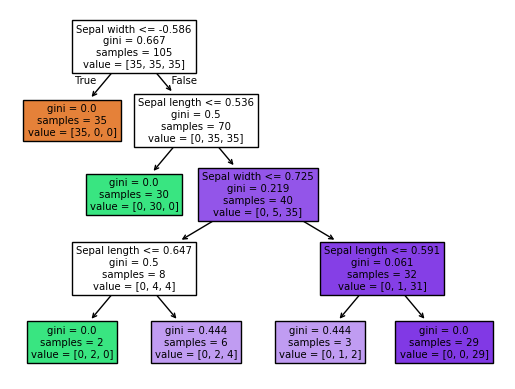

In [15]:
feature_names = ['Sepal length','Sepal width',
                 'Petal length', 'Petal width']
tree.plot_tree(tree_model, feature_names=feature_names,filled=True)

In [16]:
from sklearn.ensemble import RandomForestClassifier

In [17]:
forest = RandomForestClassifier(n_estimators=25,random_state=1,
                                n_jobs=2)
forest.fit(X_train_std,y_train)

,n_estimators,25
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


(150, 2) range(105, 140)
(35, 2)


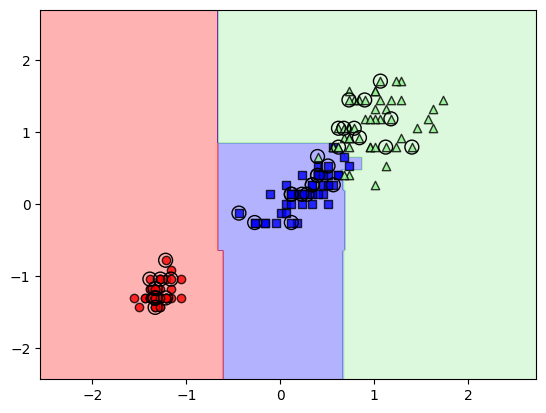

In [18]:
plot_decision_regions(X_combined,y_combined,
                      classifier=forest,
                      test_idx=range(105,140))

In [19]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
knn = KNeighborsClassifier(n_neighbors=5, p=2)

In [21]:
knn.fit(X_train_std,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


(150, 2) range(105, 140)
(35, 2)


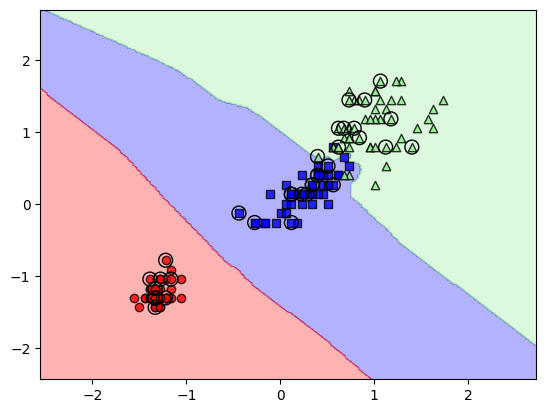

In [22]:
plot_decision_regions(X_combined,y_combined,
                      classifier=knn,
                      test_idx=range(105,140))